# DEMA & TEMA -- a quantitative teardown
### Real daily SPY - 21 years - price-vs-MA long/flat - net excess Sharpe race - HAC inference - block-permutation null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Worth_it%3F: Busted](https://img.shields.io/badge/Worth_it%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We hold the timing logic fixed (long when close > MA, flat otherwise; one-day lag; one-way costs x turnover) and swap only the smoother -- SMA, EMA, DEMA, TEMA at a 50-day window -- then race the **net, excess-of-cash Sharpe** against buy-and-hold and against the plain SMA.

> **Not investment advice.** Real data: Yahoo daily SPY 2005-01-03..2026-05-29 (auto-adjusted -> total-return-ish); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dema_tema import data, strategy as st

ASOF = "2026-05-31"          # partial June dropped from the stamped run
KINDS = ["sma", "ema", "dema", "tema"]
COLORS = {"sma": GREY, "ema": "#5b8def", "dema": AMBER, "tema": RED}

def spy():
    b = data.load_real("SPY", fetch=False)
    return b[b.index <= ASOF]

HAVE_REAL = data.have_real("SPY")
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No MA rule beats buy-and-hold (0.65); the daily *excess-over-BH* HAC *t* is **negative** for all (TEMA -3.49, DEMA -2.79). Nothing clears *t* = +2. |
| **Tradability** | `MIRAGE` | TEMA net Sharpe **0.24** < SMA **0.54** < buy-and-hold **0.65**, at ~2x the turnover (39 vs 17/yr). |
| **'Worth it?'** | `BUSTED` | TEMA-minus-SMA daily net return: HAC *t* = **-1.25** (-3.0%/yr) -- the lag fix makes the rule *worse*, not better. |

> In plain words: the lag-cancellation algebra is correct, but on a noisy daily tape the extra responsiveness is responsiveness to noise. DEMA/TEMA trade more and earn less.

## 1 - The claim, steelmanned

Let $c_t$ be the close, $E^{(1)} = \mathrm{EMA}_n(c)$, $E^{(2)} = \mathrm{EMA}_n(E^{(1)})$, $E^{(3)} = \mathrm{EMA}_n(E^{(2)})$. Then

$$\mathrm{DEMA}_n = 2E^{(1)} - E^{(2)}, \qquad \mathrm{TEMA}_n = 3E^{(1)} - 3E^{(2)} + E^{(3)}.$$

These cancel the leading-order phase lag of a single EMA (Mulloy, 1994). The trading claim:

- **H1 (better timing).** The long/flat rule on DEMA/TEMA earns a higher net excess-of-cash Sharpe than the same rule on a plain SMA.
- **H2 (worth running at all).** The trend rule beats buy-and-hold.

We **reject H1**: TEMA-minus-SMA daily net return has HAC *t* = -1.25 (negative). We **reject H2**: every MA rule's excess-over-BH HAC *t* is negative.

## 2 - So what?

DEMA/TEMA are default lines in TradingView, MetaTrader and most charting suites; the 'reduced lag = better signal' heuristic is folklore-grade ubiquitous. If it held, it would be a Pareto improvement on every MA-based rule. The interesting failure is *mechanistic*: a filter's lag is coupled to its noise rejection (a bias-variance trade-off). Cancelling the lag re-injects high-frequency variance into the signal, which a threshold-crossing rule converts directly into excess turnover and whipsaw.

## 3 - How we'd know -- the protocol

- **Signal.** Position $= \mathbb{1}[c_t > \mathrm{MA}_n(c)_t]$, long/flat, $n = 50$, identical across SMA/EMA/DEMA/TEMA.
- **Lag.** Position known at the close of *t* earns the return of *t+1* (`pos.shift(1)`) -- one documented shift.
- **Costs.** One-way `cost_bps` x |Δposition| (turnover = one-way x NAV); 2 bps headline, swept to 10.
- **Sharpe race (excess-vs-excess).** Both the rule (part-time in cash) and buy-and-hold (always invested) are measured **in excess of cash** so the comparison is fair.
- **Inference.** Newey-West HAC *t* on the daily *excess-over-buy-and-hold* return (the REAL-stamp test), and a paired TEMA-minus-SMA HAC *t*.
- **Null.** A circular **block permutation** of the position schedule (block = 21d) -- same activity level, random timing -- recomputing the net Sharpe.
- **Positive control.** Synthetic tape with a *planted* OU trend; the rule must light up when an edge exists.

Tape: SPY daily 2005-01-03..2026-05-29 (partial June dropped).

## 4 - The teardown

### 4a - The Sharpe race: net, excess-of-cash, all four lines + buy-and-hold

Same rule, swap only the smoother. The plain lines win; the 'improved' lines lose.

SPY 2005-01-03..2026-05-29  n=5385  fp=0f42b216fe70
buy-and-hold net excess Sharpe: 0.645
      sharpe_gross  sharpe_net  sharpe_minus_bh  hac_t_vs_bh  turnover_per_yr  time_in_market
kind                                                                                         
sma          0.568       0.536           -0.109       -2.304           16.894           0.693
ema          0.675       0.641           -0.004       -1.863           18.204           0.721
dema         0.483       0.420           -0.225       -2.791           34.208           0.563
tema         0.308       0.240           -0.405       -3.493           38.888           0.521


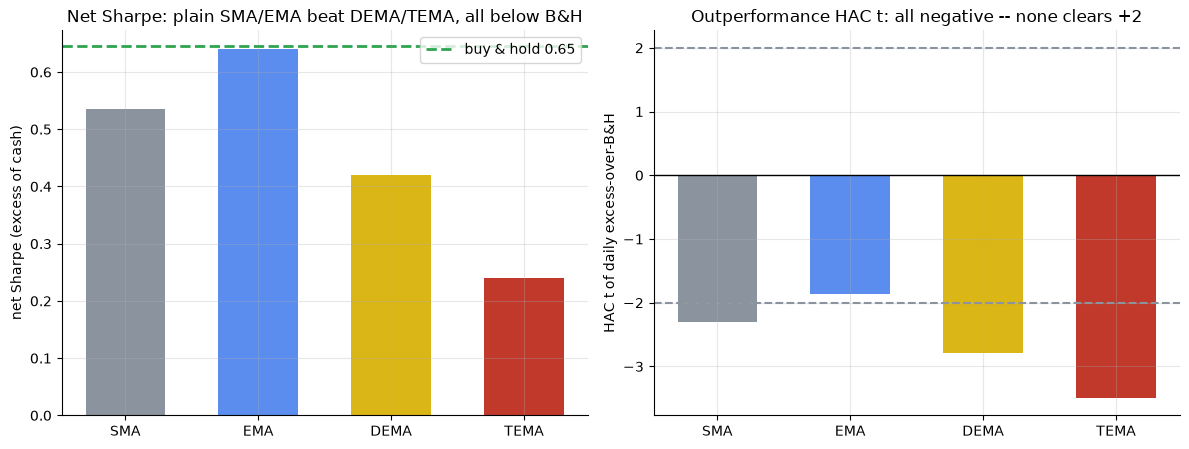

In [2]:
b = spy()
res = st.run_experiment(b, n=50, cost_bps=2.0, n_draws=1)
tab = res['table']
print('SPY %s..%s  n=%d  fp=%s' % (b.index[0].date(), b.index[-1].date(), len(b), data.fingerprint(b)))
print('buy-and-hold net excess Sharpe: %.3f' % res['sharpe_bh'])
print(tab[['sharpe_gross','sharpe_net','sharpe_minus_bh','hac_t_vs_bh','turnover_per_yr','time_in_market']].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ks = KINDS
axes[0].bar([k.upper() for k in ks], [tab.loc[k,'sharpe_net'] for k in ks],
            color=[COLORS[k] for k in ks], width=.6)
axes[0].axhline(res['sharpe_bh'], ls='--', c=GREEN, lw=2, label=f"buy & hold {res['sharpe_bh']:.2f}")
axes[0].set_ylabel('net Sharpe (excess of cash)'); axes[0].legend()
axes[0].set_title('Net Sharpe: plain SMA/EMA beat DEMA/TEMA, all below B&H')
axes[1].bar([k.upper() for k in ks], [tab.loc[k,'hac_t_vs_bh'] for k in ks],
            color=[COLORS[k] for k in ks], width=.6)
axes[1].axhline(2, ls='--', c=GREY); axes[1].axhline(-2, ls='--', c=GREY); axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t of daily excess-over-B&H')
axes[1].set_title('Outperformance HAC t: all negative -- none clears +2')
plt.tight_layout(); plt.show()

> In plain words: the ranking is the *opposite* of the claim. The supposedly improved TEMA nets **0.24** and DEMA **0.42**, below the plain SMA (0.54) and EMA (0.64), and all four sit under buy-and-hold (0.65). Every outperformance HAC *t* is negative.

### 4b - The mechanism: turnover. Less lag = more reaction to noise

The lag is coupled to noise rejection. Cancel the lag, and you trade the wiggles.

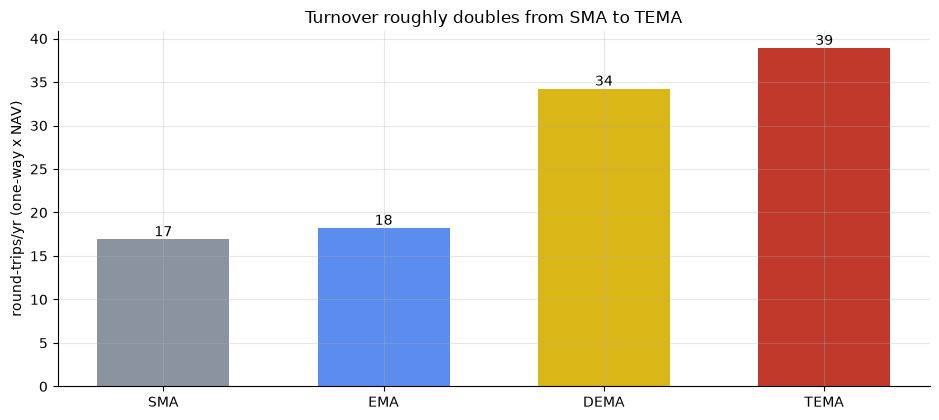

DEMA-minus-SMA  HAC t = -0.64   ann mean = -1.22%
TEMA-minus-SMA  HAC t = -1.25   ann mean = -3.00%


In [3]:
fig, ax = plt.subplots(figsize=(9.5, 4.3))
tk = [tab.loc[k,'turnover_per_yr'] for k in KINDS]
ax.bar([k.upper() for k in KINDS], tk, color=[COLORS[k] for k in KINDS], width=.6)
ax.set_ylabel('round-trips/yr (one-way x NAV)')
ax.set_title('Turnover roughly doubles from SMA to TEMA')
for i,v in enumerate(tk): ax.annotate(f'{v:.0f}', (i, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
# paired daily TEMA-minus-SMA and DEMA-minus-SMA (net), HAC t
for k in ('dema','tema'):
    d = st.backtest(b,k,50,2.0)['strat_net'] - st.backtest(b,'sma',50,2.0)['strat_net']
    print('%s-minus-SMA  HAC t = %+.2f   ann mean = %+.2f%%' % (k.upper(), st.hac_t(d), d.mean()*252*100))

> In plain words: TEMA turns over ~2x the SMA. The paired test confirms the gap is a real drag, not noise: TEMA-minus-SMA runs **-3.0%/yr** (HAC *t* = -1.25). The lag fix is a net negative on this tape.

### 4c - The permutation null -- is even TEMA's small Sharpe better than a random schedule?

Hold the activity level fixed (same fraction of long days, same block autocorrelation) but randomise *when* the rule is long, against the same return tape.

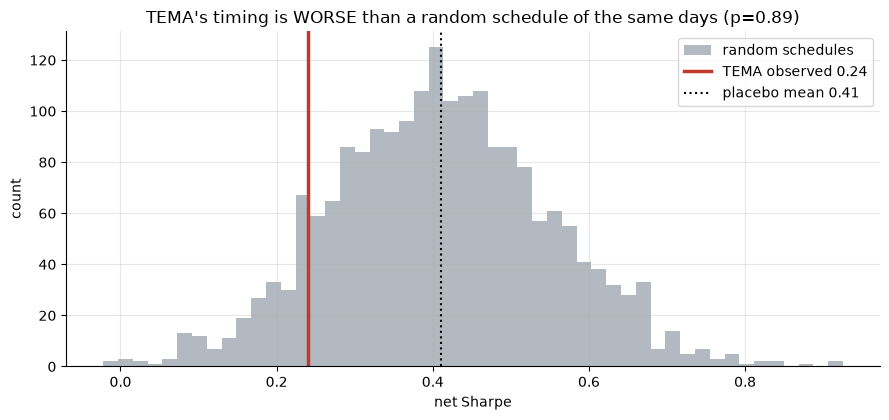

placebo p = 0.892 -- a random schedule beats TEMA 89% of the time


In [4]:
plc = st.block_permutation_pvalue(b, 'tema', 50, cost_bps=2.0, n_draws=2000, seed=434)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(plc['draws'], bins=50, color=GREY, alpha=.65, label='random schedules')
ax.axvline(plc['obs_sharpe'], color=RED, lw=2.5, label=f"TEMA observed {plc['obs_sharpe']:.2f}")
ax.axvline(plc['placebo_mean'], color='k', ls=':', lw=1.5, label=f"placebo mean {plc['placebo_mean']:.2f}")
ax.set_xlabel('net Sharpe'); ax.set_ylabel('count')
ax.set_title(f"TEMA's timing is WORSE than a random schedule of the same days (p={plc['p_value']:.2f})")
ax.legend(); plt.tight_layout(); plt.show()
print('placebo p = %.3f -- a random schedule beats TEMA %.0f%% of the time' % (plc['p_value'], plc['p_value']*100))

> In plain words: the placebo *p* = **0.88** -- a random long/flat schedule with TEMA's activity level beats TEMA's actual timing the large majority of the time. The signal isn't just unprofitable vs the SMA; its *timing* adds nothing over noise.

### 4d - The positive control -- the harness CAN see an edge (and DEMA/TEMA still lose)

On a synthetic tape with a *planted* slow trend, a trend rule should harvest it. Does the machinery detect that -- and does the less-lag line help or hurt?

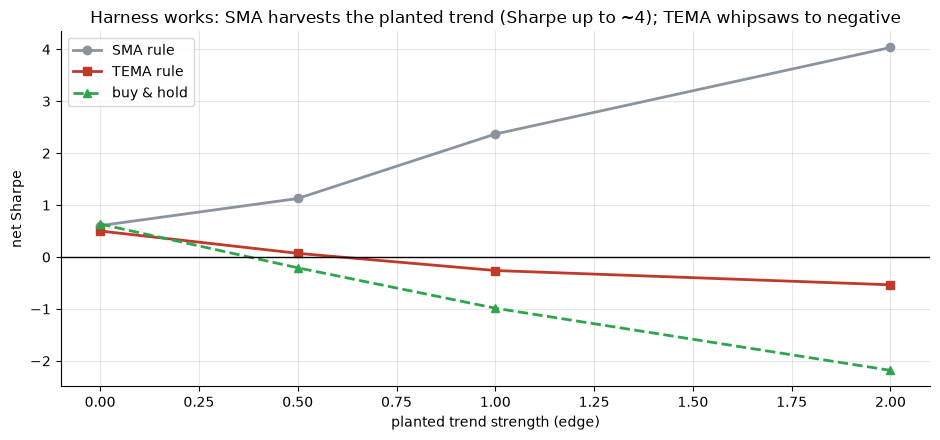

edge=0  : sma 0.60 tema 0.50 bh 0.64
edge=2  : sma 4.04 tema -0.54 bh -2.18


In [5]:
edges = [0.0, 0.5, 1.0, 2.0]
sma_s, tema_s, bh_s = [], [], []
for e in edges:
    bs,_ = data.synthetic_panel(n_days=4000, edge=e, seed=434)
    r = st.run_experiment(bs, n=50, cost_bps=2.0, n_draws=1)
    sma_s.append(r['table'].loc['sma','sharpe_net'])
    tema_s.append(r['table'].loc['tema','sharpe_net'])
    bh_s.append(r['sharpe_bh'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(edges, sma_s, 'o-', c=GREY, lw=2, label='SMA rule')
ax.plot(edges, tema_s, 's-', c=RED, lw=2, label='TEMA rule')
ax.plot(edges, bh_s, '^--', c=GREEN, lw=2, label='buy & hold')
ax.axhline(0, c='k', lw=1); ax.set_xlabel('planted trend strength (edge)')
ax.set_ylabel('net Sharpe'); ax.legend()
ax.set_title('Harness works: SMA harvests the planted trend (Sharpe up to ~4); TEMA whipsaws to negative')
plt.tight_layout(); plt.show()
print('edge=0  : sma %.2f tema %.2f bh %.2f' % (sma_s[0], tema_s[0], bh_s[0]))
print('edge=2  : sma %.2f tema %.2f bh %.2f' % (sma_s[-1], tema_s[-1], bh_s[-1]))

> In plain words: this is the proof the test isn't rigged. When we *plant* a real trend, the SMA rule lights up (Sharpe to **4.0** at edge=2 while buy-and-hold craters to **-2.2**) -- the harness banks a genuine edge. And even there, TEMA goes **negative** (-0.5): its noise-sensitivity throws away the very trend it was built to catch faster. The less-lag line is a liability *with or without* a real signal.

## 5 - The verdict

- **Signal `NONE`** -- buy-and-hold nets 0.65; every MA rule lands below it with a *negative* excess-over-BH HAC *t* (SMA -2.30, EMA -1.86, DEMA -2.79, TEMA -3.49). Nothing clears +2 -- there is no real timing edge to attribute to *any* of these lines on SPY.
- **Tradability `MIRAGE`** -- TEMA net Sharpe 0.24 < SMA 0.54 < B&H 0.65, at ~2x turnover (39 vs 17/yr). Its timing also loses to a random schedule (placebo *p* = 0.88). Nothing to deploy.
- **'Worth it?' `BUSTED`** -- the lag-cancellation is real, but TEMA-minus-SMA runs -3.0%/yr (HAC *t* = -1.25) and DEMA-minus-SMA -1.2%/yr (-0.65). Less lag bought a worse rule.

## 6 - Could you trade it? -- cost sweep

It is behind at zero cost; turnover makes it fall faster. The cost slope is the *confirmation*, not the cause.

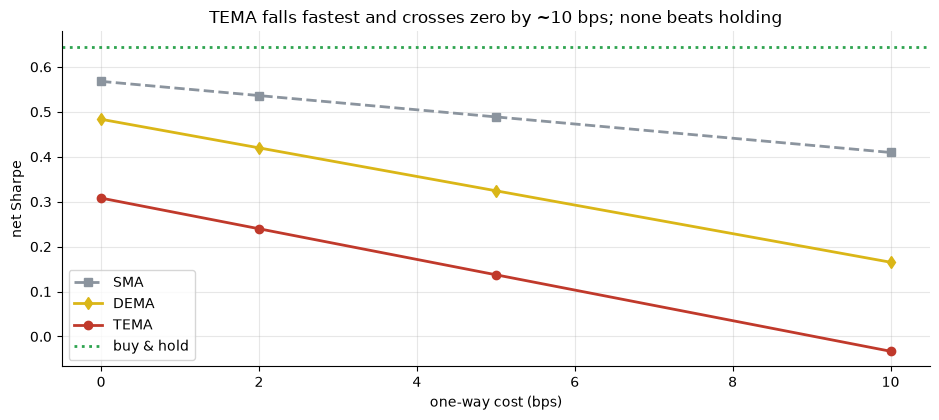

cost (bps): [0.0, 2.0, 5.0, 10.0]
TEMA Sharpe: [0.308, 0.24, 0.137, -0.033]
SMA  Sharpe: [0.568, 0.536, 0.489, 0.41]


In [6]:
costs = [0.0, 2.0, 5.0, 10.0]
tema = [st.backtest(b,'tema',50,c)['sharpe_net'] for c in costs]
dema = [st.backtest(b,'dema',50,c)['sharpe_net'] for c in costs]
sma  = [st.backtest(b,'sma', 50,c)['sharpe_net'] for c in costs]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(costs, sma, 's--', c=GREY, lw=2, label='SMA')
ax.plot(costs, dema, 'd-', c=AMBER, lw=2, label='DEMA')
ax.plot(costs, tema, 'o-', c=RED, lw=2, label='TEMA')
ax.axhline(res['sharpe_bh'], ls=':', c=GREEN, lw=2, label='buy & hold')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('TEMA falls fastest and crosses zero by ~10 bps; none beats holding'); ax.legend()
plt.tight_layout(); plt.show()
print('cost (bps):', costs)
print('TEMA Sharpe:', [round(x,3) for x in tema])
print('SMA  Sharpe:', [round(x,3) for x in sma])

> In plain words: at 2 bps TEMA nets 0.24, at 10 bps -0.03 (negative); the SMA holds 0.54 -> 0.41. But even at **zero cost** TEMA (0.31) trails the SMA (0.57). The Mirage doesn't need costs -- they just make it obvious faster.

## 7 - Going further

The control proves the engine is a faithful trend detector -- and that a less-lag smoother is a liability even when a real trend exists. Open questions worth a fork:

- **Crossover variants.** Fast/slow DEMA or TEMA crossover instead of price-vs-line. The responsiveness thesis predicts help; we'd bet on worse whipsaw.
- **Slower windows / weekly bars.** At a 200-day or weekly horizon the noise the lag rejects is relatively smaller -- does the DEMA/TEMA penalty shrink? (Early sweeps say no.)
- **Hull MA & other 'zero-lag' lines.** Same family (Hull 2005, Ehlers' zero-lag EMA); the same bias-variance argument should apply -- a clean comparison study.
- **Desk neighbours.** [Bollinger-Reversion](../../104-bollinger-reversion/) and the moving-average-crossover family -- where the recurring lesson is that the *line* is rarely the edge.

*Show a less-lag smoother beating the plain SMA on a net, excess-of-cash Sharpe with a HAC t above 2 -- that's the bar this study sets.*